#Homework 5: Neural Networks with Keras
**Amrit Dhillon**

**Imports and Loading Data**

In [1]:
#!pip install optuna

import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


In [3]:
#load data
adult = pd.read_csv('/adult.csv')

#drop any rows with missing values
adult.dropna(inplace=True)

#encode target: >50K = 1, <=50K = 0
adult['income'] = adult['income'].apply(lambda x: 1 if x == '>50K' else 0)

#one-hot encode categorical columns
adult = pd.get_dummies(adult, columns=['workclass', 'education', 'marital-status',
                                       'occupation', 'relationship', 'race',
                                       'gender', 'native-country'],
                       drop_first=True)

print(adult.shape)
adult.head()

(48842, 101)


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False


**Scaling and Splitting**

In [4]:
X = adult.drop('income', axis=1)
y = adult['income'].to_numpy()

#splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size: ", X_test_scaled.shape)
print("Input features:", X_train_scaled.shape[1])

Train size: (39073, 100)
Test size:  (9769, 100)
Input features: 100


**Baseline Model**

In [5]:
tf.random.set_seed(42)

n_features = X_train_scaled.shape[1]

inputs  = keras.Input(shape=(n_features,))
x       = layers.Dense(64, activation='relu')(inputs)
x       = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

baseline_model = keras.Model(inputs=inputs, outputs=outputs, name='baseline')
baseline_model.summary()

baseline_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8092 - loss: 0.3945 - val_accuracy: 0.8398 - val_loss: 0.3352
Epoch 2/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8490 - loss: 0.3239 - val_accuracy: 0.8470 - val_loss: 0.3265
Epoch 3/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8549 - loss: 0.3128 - val_accuracy: 0.8498 - val_loss: 0.3239
Epoch 4/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8573 - loss: 0.3065 - val_accuracy: 0.8505 - val_loss: 0.3236
Epoch 5/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8578 - loss: 0.3023 - val_accuracy: 0.8509 - val_loss: 0.3241
Epoch 6/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8598 - loss: 0.2991 - val_accuracy: 0.8513 - val_loss: 0.3245
Epoch 7/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8608 - loss: 0.2965 - val_accuracy: 0.8509 - val_loss: 0.3252
Epoch 8/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8616 - loss: 0.2943 - val_accuracy:

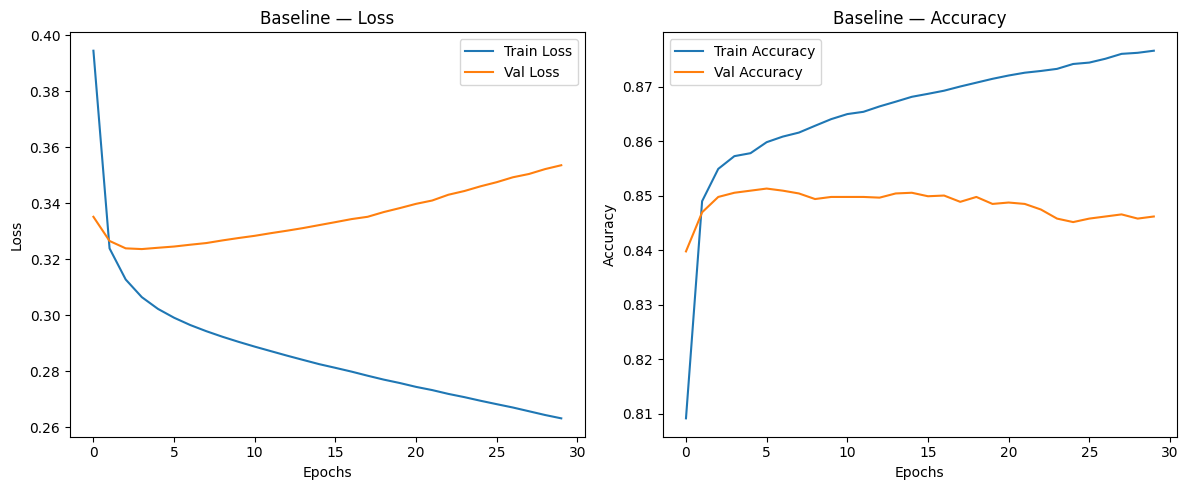

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'],     label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline — Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'],     label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline — Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

**Three Configurations of the Baseline**

In [11]:
#Configuration 1: wider layers (more neurons per layer)
tf.random.set_seed(42)

inputs  = keras.Input(shape=(n_features,))
x       = layers.Dense(128, activation='relu')(inputs)
x       = layers.Dense(64,  activation='relu')(x)
outputs = layers.Dense(1,   activation='sigmoid')(x)

model_wide = keras.Model(inputs=inputs, outputs=outputs, name='wide')
model_wide.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

history_wide = model_wide.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

val_acc_wide = max(history_wide.history['val_accuracy'])
print(f"Experiment 1 (Wider) — Best Val Accuracy: {val_acc_wide:.4f}")

Epoch 1/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8370 - loss: 0.3559 - val_accuracy: 0.8457 - val_loss: 0.3293
Epoch 2/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8530 - loss: 0.3156 - val_accuracy: 0.8481 - val_loss: 0.3248
Epoch 3/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8579 - loss: 0.3059 - val_accuracy: 0.8490 - val_loss: 0.3248
Epoch 4/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8605 - loss: 0.3002 - val_accuracy: 0.8514 - val_loss: 0.3254
Epoch 5/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8620 - loss: 0.2960 - val_accuracy: 0.8509 - val_loss: 0.3266
Epoch 6/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8629 - loss: 0.2927 - val_accuracy: 0.8505 - val_loss: 0.3270
Epoch 7/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8649 - loss: 0.2894 - val_accuracy: 0.8509 - val_loss: 0.3276
Epoch 8/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8660 - loss: 0.2866 - val_accuracy:

In [12]:
#Configuration 2: deeper (more hidden layers, same neuron count per layer)
tf.random.set_seed(42)

inputs  = keras.Input(shape=(n_features,))
x       = layers.Dense(64, activation='relu')(inputs)
x       = layers.Dense(64, activation='relu')(x)
x       = layers.Dense(64, activation='relu')(x)
x       = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1,  activation='sigmoid')(x)

model_deep = keras.Model(inputs=inputs, outputs=outputs, name='deep')
model_deep.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

history_deep = model_deep.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

val_acc_deep = max(history_deep.history['val_accuracy'])
print(f"Experiment 2 (Deeper) — Best Val Accuracy: {val_acc_deep:.4f}")

Epoch 1/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8282 - loss: 0.3715 - val_accuracy: 0.8401 - val_loss: 0.3356
Epoch 2/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8498 - loss: 0.3204 - val_accuracy: 0.8454 - val_loss: 0.3293
Epoch 3/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8556 - loss: 0.3094 - val_accuracy: 0.8458 - val_loss: 0.3287
Epoch 4/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8576 - loss: 0.3030 - val_accuracy: 0.8490 - val_loss: 0.3287
Epoch 5/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8598 - loss: 0.2984 - val_accuracy: 0.8494 - val_loss: 0.3298
Epoch 6/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8622 - loss: 0.2941 - val_accuracy: 0.8496 - val_loss: 0.3329
Epoch 7/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8634 - loss: 0.2907 - val_accuracy: 0.8493 - val_loss: 0.3352
Epoch 8/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8658 - loss: 0.2870 - val_accuracy: 0.

In [13]:
#Configuration 3: same baseline architecture but with dropout and L2 Regularization
tf.random.set_seed(42)

inputs = keras.Input(shape=(n_features,))

x = layers.Dense(64, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
x = layers.Dropout(0.3)(x)

x = layers.Dense(32, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_reg = keras.Model(inputs=inputs, outputs=outputs, name='regularized')
model_reg.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_reg = model_reg.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=100,           #early stopping may stop earlier
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

val_acc_reg = max(history_reg.history['val_accuracy'])
print(f"Experiment 3 (Dropout+L2) — Best Val Accuracy: {val_acc_reg:.4f}")
print(f"Stopped at epoch: {len(history_reg.history['loss'])}")

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8037 - loss: 0.9502 - val_accuracy: 0.8385 - val_loss: 0.5265
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8401 - loss: 0.4494 - val_accuracy: 0.8452 - val_loss: 0.3898
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8457 - loss: 0.3800 - val_accuracy: 0.8462 - val_loss: 0.3640
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8454 - loss: 0.3659 - val_accuracy: 0.8448 - val_loss: 0.3581
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8475 - loss: 0.3616 - val_accuracy: 0.8456 - val_loss: 0.3548
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8476 - loss: 0.3588 - val_accuracy: 0.8461 - val_loss: 0.3541
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8460 - loss: 0.3589 - val_accuracy: 0.8454 - val_loss: 0.3537
Epoch 8/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8462 - loss: 0.3571 - val_accu

**Comparing Baseline vs Configurations**

Experiment Comparison (Best Val Accuracy):
  Baseline  (64→32):          0.8513
  Exp 1 - Wider (128→64):     0.8516
  Exp 2 - Deeper (64×3→32):   0.8499
  Exp 3 - Dropout+L2 (64→32): 0.8507


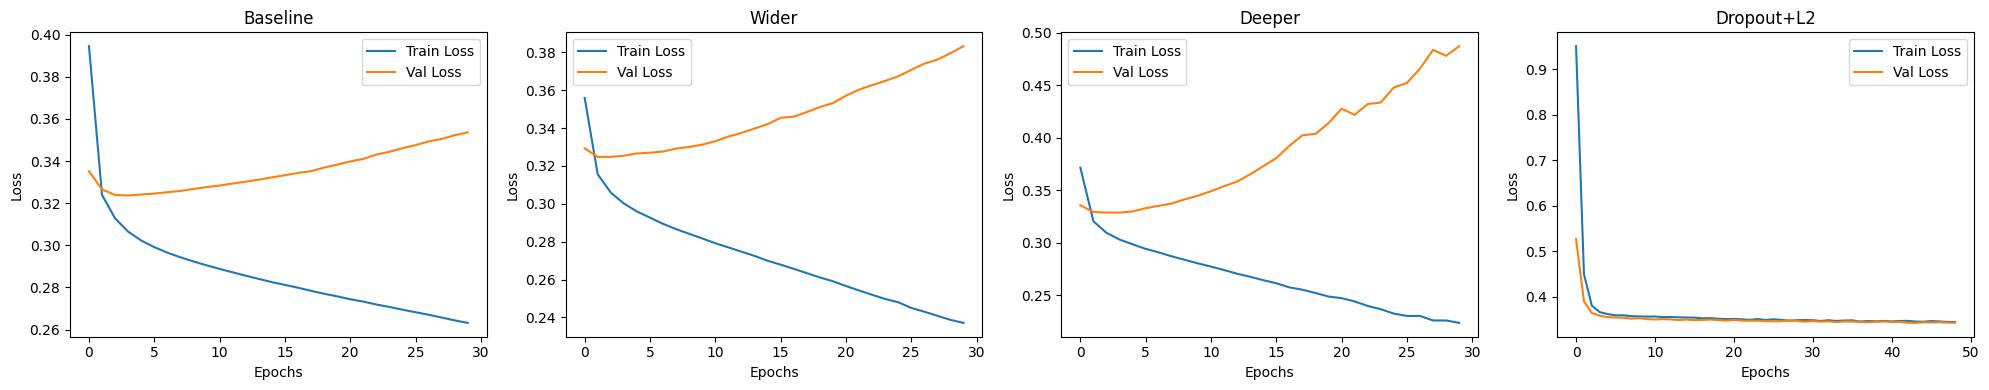

In [14]:
val_acc_baseline = max(history_baseline.history['val_accuracy'])
val_acc_wide     = max(history_wide.history['val_accuracy'])
val_acc_deep     = max(history_deep.history['val_accuracy'])
val_acc_reg      = max(history_reg.history['val_accuracy'])

print("Experiment Comparison (Best Val Accuracy):")
print(f"  Baseline  (64→32):          {val_acc_baseline:.4f}")
print(f"  Exp 1 - Wider (128→64):     {val_acc_wide:.4f}")
print(f"  Exp 2 - Deeper (64×3→32):   {val_acc_deep:.4f}")
print(f"  Exp 3 - Dropout+L2 (64→32): {val_acc_reg:.4f}")

#plot loss curves side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, hist, label in zip(
    axes,
    [history_baseline, history_wide, history_deep, history_reg],
    ['Baseline', 'Wider', 'Deeper', 'Dropout+L2']
):
    ax.plot(hist.history['loss'],     label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(label)
    ax.set_xlabel('Epochs'); ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.show()

**Optuna Tuning**

In [15]:
def objective(trial):
    num_layers    = trial.suggest_int('num_layers', 1, 3)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [64, 128, 256])
    units_1       = trial.suggest_int('units_1', 16, 128)
    units_2       = trial.suggest_int('units_2', 16, 128)
    units_3       = trial.suggest_int('units_3', 16, 128)

    tf.random.set_seed(42)
    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(units_1, activation='relu')(inputs)
    if num_layers >= 2:
        x = layers.Dense(units_2, activation='relu')(x)
    if num_layers >= 3:
        x = layers.Dense(units_3, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled, y_train,
        batch_size=batch_size,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    return min(history.history['val_loss'])


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-21 16:04:11,679] A new study created in memory with name: no-name-4ee5ab0d-9c7a-4188-961c-cf65c8da40ab
[I 2026-05-21 16:04:24,055] Trial 0 finished with value: 0.3258030116558075 and parameters: {'num_layers': 3, 'learning_rate': 0.004454355294517826, 'batch_size': 128, 'units_1': 67, 'units_2': 103, 'units_3': 33}. Best is trial 0 with value: 0.3258030116558075.
[I 2026-05-21 16:04:59,735] Trial 1 finished with value: 0.3284775912761688 and parameters: {'num_layers': 3, 'learning_rate': 0.0007379760736987267, 'batch_size': 64, 'units_1': 37, 'units_2': 91, 'units_3': 78}. Best is trial 0 with value: 0.3258030116558075.
[I 2026-05-21 16:05:14,860] Trial 2 finished with value: 0.32735490798950195 and parameters: {'num_layers': 2, 'learning_rate': 0.004184883741311513, 'batch_size': 128, 'units_1': 122, 'units_2': 66, 'units_3': 18}. Best is trial 0 with value: 0.3258030116558075.
[I 2026-05-21 16:05:20,176] Trial 3 finished with value: 0.3253459930419922 and parameters: {'num

Best validation loss: 0.3222779929637909
Best parameters: {'num_layers': 1, 'learning_rate': 0.0004042925989259501, 'batch_size': 256, 'units_1': 61, 'units_2': 128, 'units_3': 104}


**Optuna Model Evaluation**

In [16]:
optuna.visualization.plot_optimization_history(study)

In [17]:
optuna.visualization.plot_param_importances(study)

In [18]:
best_params   = study.best_params
num_layers    = best_params['num_layers']
learning_rate = best_params['learning_rate']
batch_size    = best_params['batch_size']
units_1       = best_params['units_1']
units_2       = best_params['units_2']
units_3       = best_params['units_3']

tf.random.set_seed(42)

inputs = keras.Input(shape=(n_features,))
x = layers.Dense(units_1, activation='relu')(inputs)
if num_layers >= 2:
    x = layers.Dense(units_2, activation='relu')(x)
if num_layers >= 3:
    x = layers.Dense(units_3, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

final_model = keras.Model(inputs=inputs, outputs=outputs)
final_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=['accuracy']
)

history_final = final_model.fit(
    X_train_scaled, y_train,
    batch_size=batch_size,
    epochs=100,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7619 - loss: 0.5035 - val_accuracy: 0.8229 - val_loss: 0.3920
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8336 - loss: 0.3678 - val_accuracy: 0.8371 - val_loss: 0.3520
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8413 - loss: 0.3434 - val_accuracy: 0.8394 - val_loss: 0.3411
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8445 - loss: 0.3339 - val_accuracy: 0.8415 - val_loss: 0.3362
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8467 - loss: 0.3280 - val_accuracy: 0.8418 - val_loss: 0.3330
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8490 - loss: 0.3235 - val_accuracy: 0.8448 - val_loss: 0.3304
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8505 - loss: 0.3197 - val_accuracy: 0.8464 - val_loss: 0.3283
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8524 - loss: 0.3163 - val_a

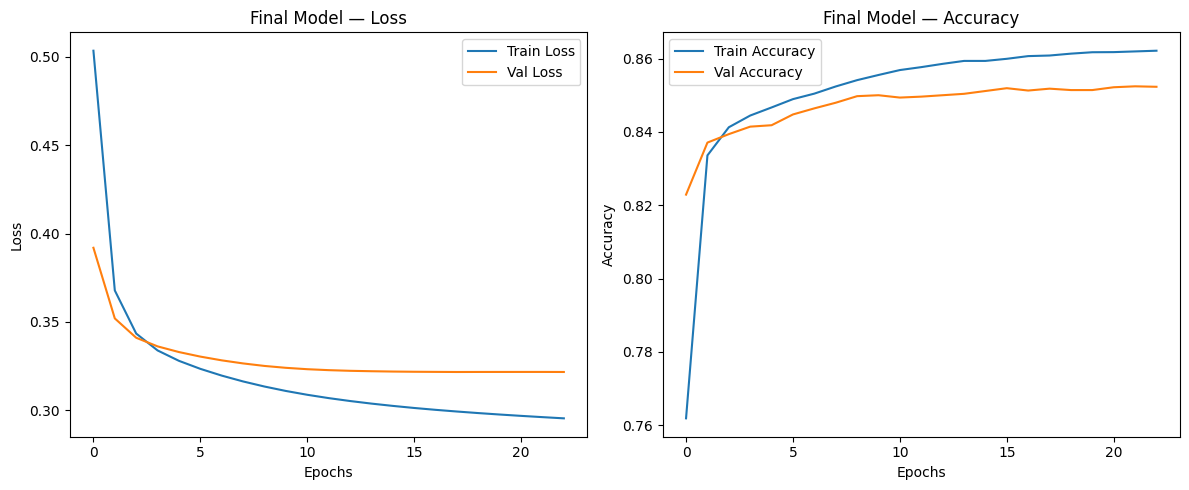

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'],     label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Val Loss')
plt.title('Final Model — Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'],     label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Val Accuracy')
plt.title('Final Model — Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

**Predicting on Test Set**

In [20]:
#predict on the test set
y_pred_prob = final_model.predict(X_test_scaled)
y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("\nFinal Model — Test Set Evaluation:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  ROC AUC:   {roc_auc:.4f}")

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Final Model — Test Set Evaluation:
  Accuracy:  0.8552
  Precision: 0.7385
  Recall:    0.6112
  F1 Score:  0.6689
  ROC AUC:   0.9085


**Conclusion + Personal Workflow**

*Conclusion*

In this assignment, I built a baseline neural network on the census dataset and improved it through multiple experiments and tuning. My baseline model (64→32 hidden layers) reached strong validation performance, and I then tested three meaningful configuration changes. I tested a wider network, a deeper network, and a regularized version with early dropout + L2.

To isolate effects, I changed one factor at a time in key experiments (width-only and depth-only), then tested regularization as a separate setup. Based on validation behavior, the wider model gave a small improvement over baseline, while the deeper model did not clearly improve generalization. The early dropout + L2 model was more stable but did not outperform the best validation result from the simpler architectures.

I then used Optuna as a systematic tuning method to search over number of layers, layer sizes, learning rate, and batch size. The tuned final model performed well on the held-out test set, with approximately:

- Accuracy: 0.855
- Precision: 0.739
- Recall: 0.611
- F1: 0.669
- ROC AUC: 0.909

These results show that the final tuned neural network generalizes well, with especially strong ranking/separation performance (ROC AUC), while still leaving room to improve recall through threshold tuning in future work.

*Personal Workflow*

For future neural network tasks, this is the workflow I would reuse based on what worked and what didn't:

1. Set up preprocessing and keep it consistent.
Handle target encoding, one-hot encoding, and scaling once, then reuse the same pipeline across all experiments

2. Start with a simple baseline first. Build a small MLP with standard preprocessing so I have a stable reference point

3. Run controlled experiments (one change at a time).
Test width, depth, and regularization separately before combining ideas so I can clearly explain what helped and what did not

4. Track both metrics and learning behavior and use validation curves (loss/val_loss) alongside performance metrics, because similar accuracy can still hide overfitting

5. Apply systematic tuning after manual experiments to tune across a wider range of parameters. I liked using Optuna to tune learning rate, layer count, units, and batch size once I know the general architecture direction as I've previously used it

6. Evaluate on the held-out test set, and do all model selection with train/validation first, keeping test data untouched until final evaluation

7. To choose my final model, I would prefer the simplest model that performs competitively. Same thing as past notebooks where if a more complex model only gives tiny gains, I'd choose the simpler option for better stability and interpretability.


*Pitfalls/Things I Want to Avoid Next Time*

- Treating deeper networks as automatically better, even when they add complexity without validation gains
- Using only accuracy on an imbalanced target and missing class-level behavior (precision/recall/F1)